In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


In [70]:
train_df=pd.read_csv("/kaggle/input/titanic/train.csv")
test_df=pd.read_csv("/kaggle/input/titanic/test.csv")

In [71]:
train_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [72]:
train_df.drop("PassengerId",axis=1,inplace=True)

In [73]:
train_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [74]:
train_df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

- Survived: that's the target, 0 means the passenger did not survive, while 1 means he/she survived.
- Pclass: passenger class.
- Name, Sex, Age: self-explanatory.
- SibSp: how many siblings & spouses of the passenger aboard the Titanic.
- Parch: how many children & parents of the passenger aboard the Titanic.
- Ticket: ticket id
- Fare: price paid (in pounds)
- Cabin: passenger's cabin number
- Embarked: where the passenger embarked the Titanic




In [75]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [76]:
print("Cabin Null Count: ",train_df['Cabin'].isnull().sum()/len(train_df)*100) 
print("Age Null Count: ",train_df['Age'].isnull().sum()/len(train_df)*100)
print("Embarked Null count: ",train_df["Embarked"].isnull().sum()/len(train_df)*100)

Cabin Null Count:  77.10437710437711
Age Null Count:  19.865319865319865
Embarked Null count:  0.22446689113355783


- Cabin has almost 77% null values.Let's ignore it for now.
- Age null count is almost 19.8%. Now impute this.


In [77]:
 train_df.sample(10)

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
123,1,2,"Webber, Miss. Susan",female,32.5,0,0,27267,13.000,E101,S
439,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.500,NaN,S
744,1,3,"Stranden, Mr. Juho",male,31.0,0,0,STON/O 2. 3101288,7.925,NaN,S
539,1,1,"Frolicher, Miss. Hedwig Margaritha",female,22.0,0,2,13568,49.500,B39,C
63,0,3,"Skoog, Master. Harald",male,4.0,3,2,347088,27.900,NaN,S
846,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.550,NaN,S
273,0,1,"Natsch, Mr. Charles H",male,37.0,0,1,PC 17596,29.700,C118,C
585,1,1,"Taussig, Miss. Ruth",female,18.0,0,2,110413,79.650,E68,S
814,0,3,"Tomlin, Mr. Ernest Portage",male,30.5,0,0,364499,8.050,NaN,S
454,0,3,"Peduzzi, Mr. Joseph",male,NaN,0,0,A/5 2817,8.050,NaN,S


In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='Age', ylabel='Count'>

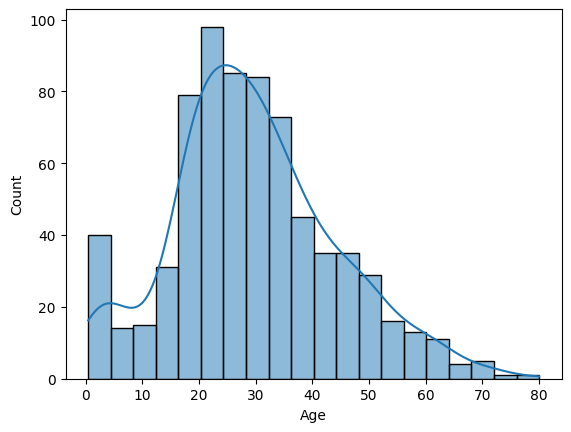

In [79]:
sns.histplot(data=train_df,x='Age',kde=True)

In [80]:
print("Male Median Age: ",train_df[train_df['Sex']=="male"]['Age'].median())
print("Female Median Age: ",train_df[train_df['Sex']=='female']['Age'].median())
print("Pclass 1 Median Age: ",train_df[train_df['Pclass']==1]['Age'].median())
print("Pclass 2 Median Age: ",train_df[train_df['Pclass']==2]['Age'].median())
print("Pclass 3 Median Age: ",train_df[train_df['Pclass']==3]['Age'].median())


Male Median Age:  29.0
Female Median Age:  27.0
Pclass 1 Median Age:  37.0
Pclass 2 Median Age:  29.0
Pclass 3 Median Age:  24.0


In [26]:
print("Null count in Pclass 1: ",train_df[train_df['Pclass']==1]['Age'].isnull().sum())
print("Null count in Pclass 2: ",train_df[train_df['Pclass']==2]['Age'].isnull().sum())
print("Null count in Pclass 3: ",train_df[train_df['Pclass']==3]['Age'].isnull().sum())

Null count in Pclass 1:  30
Null count in Pclass 2:  11
Null count in Pclass 3:  136



# Here median Age of people in each class has much different median age. Lets first fill the null value with `median age` and try other methods alsoz

In [81]:
train_df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [82]:
train_df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [83]:
train_df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

In [84]:
train_df[train_df['Survived']==1]['Sex'].value_counts()

Sex
female    233
male      109
Name: count, dtype: int64

- Feamles have higher survaival rate than that of Men.

In [85]:
train_df["Pclass"].value_counts()


Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [86]:
train_df[train_df['Survived']==1]['Pclass'].value_counts()/len(train_df)*100

Pclass
1    15.263749
3    13.355780
2     9.764310
Name: count, dtype: float64

In [87]:
train_df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [38]:
# Building Preprocessing Pipelines.

In [41]:
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

In [42]:
num_pipeline=Pipeline([
    ("imputer",SimpleImputer(strategy='median')),
    ("scaler",StandardScaler())
])

In [43]:
from sklearn.preprocessing import OneHotEncoder

In [52]:
cat_pipeline=Pipeline([
     ("imputer",SimpleImputer(strategy='most_frequent')),
    ('cat_encoder',OneHotEncoder(sparse_output=False))
])

In [53]:
from sklearn.compose import ColumnTransformer

In [89]:
y_train=train_df['Survived']
num_cols=["Age","SibSp","Parch","Fare"]
cat_cols=["Pclass","Sex","Embarked"]

In [63]:
preprocess_pipeline=ColumnTransformer(transformers=[
    ("num",num_pipeline,num_cols),
    ("cat",cat_pipeline,cat_cols)
])

In [64]:
train_df=train_df[num_cols+cat_cols]

In [91]:
X_train=preprocess_pipeline.fit_transform(train_df)

In [92]:
X_train

array([[-0.56573646,  0.43279337, -0.47367361, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.66386103,  0.43279337, -0.47367361, ...,  1.        ,
         0.        ,  0.        ],
       [-0.25833709, -0.4745452 , -0.47367361, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.1046374 ,  0.43279337,  2.00893337, ...,  0.        ,
         0.        ,  1.        ],
       [-0.25833709, -0.4745452 , -0.47367361, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.20276197, -0.4745452 , -0.47367361, ...,  0.        ,
         1.        ,  0.        ]])

In [96]:
from sklearn.ensemble import RandomForestClassifier


In [99]:
forest=RandomForestClassifier(random_state=42,n_estimators=100)
forest.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [101]:
y_pred=forest.predict(X_train)

In [102]:
from sklearn import metrics

- Here dataset is not that much imbalanced. so lets use Accuracy for model evaluation

In [103]:
metrics.accuracy_score(y_train,y_pred)

0.9797979797979798

- Here Accuracy in training set is 97%. Let's see whether the model is overfitting the data or not

In [120]:
from sklearn.model_selection import cross_val_score
corss_val_score_forest=cross_val_score(forest,X_train,y_train,cv=10)


In [126]:
corss_val_score_forest.mean()

0.8092759051186016

- Here trainng accuracy is much higher that that of validation accuracy hence the model is overfitting the data.


In [123]:
print("Precision Score: ",metrics.precision_score(y_train,y_pred))
print("Recall Score:- ",metrics.recall_score(y_train,y_pred))

Precision Score:  0.990909090909091
Recall Score:-  0.956140350877193


In [110]:
# lets use another model
from sklearn.svm import SVC

In [111]:
svm_clf=SVC(gamma='auto')
svm_clf.fit(X_train,y_train)

SVC(gamma='auto')

In [114]:
accuracy=metrics.accuracy_score(y_train,svm_clf.predict(X_train))
accuracy

0.8327721661054994

In [129]:
cross_val_score_svm=cross_val_score(svm_clf,X_train,y_train,cv=10)

In [132]:
cross_val_score_svm.mean()

0.8249313358302123

- Here Training Accuracy and Validation accuracy is almost equal. Model is generalizing the unseen data well.

In [136]:
df=pd.DataFrame({
    'random_forest':corss_val_score_forest,
    'svm':cross_val_score_svm
})
df

,random_forest,svm
0,0.744444,0.811111
1,0.797753,0.853933
2,0.752809,0.775281
3,0.808989,0.876404
4,0.876404,0.831461
5,0.831461,0.797753
6,0.831461,0.820225
7,0.775281,0.786517
8,0.831461,0.853933
9,0.842697,0.842697


Text(0.5694444444444446, 0.5, 'Validation Accuracy')

<Figure size 100x100 with 0 Axes>

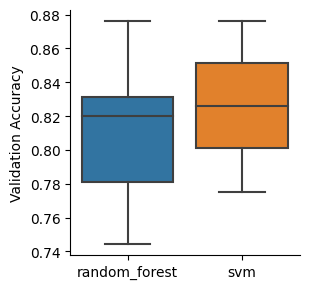

In [146]:
plt.figure(figsize=(1,1))
sns.catplot(data=df,kind='box',height=3)
plt.ylabel("Validation Accuracy")

#### Key Ovservations
- Here Svm median line is slightly above than random forest median line, so SVM is more Stable  to unseen data
- Interquartile Range:- Interquartile range of SVM is narrower that random forest. So, SVM has more stable preformance.
-  Whiskers:- The whiskers shows the rane of accuracy scores. SVM has narrow range of Accuracy than random forest.

In [147]:
# Lets create a new features and  see the accuracy